![](./imgs/timelinedl.png)

# Classic Machine Learning

![](./imgs/classic_ml.png)

# Deep Learning

![](./imgs/dl_pipeline.png)

Deep Learning model has layers.

## Layer - a building block for NNs
- Dense/Linear/FC layer: $f(x)=Wx+b$
- Nonlinear layer: $f(x) = \sigma(x)$
- Input layer, Output layer

## Activation Function - function applied to layer output
- Sigmoid
- tanh
- ReLU
- Any other function to get nonlinear intermediate signal in NN

## Backpropagation - a fancy word for "chain rule"

## Networks can be deep

![](./imgs/vgg-16.png)

## Much deeper...

![](./imgs/googlenet.png)

# Backpropagation

![](./imgs/1.png)

![](./imgs/2.png)

![](./imgs/3.png)

![](./imgs/4.png)

![](./imgs/5.png)

![](./imgs/6.png)

![](./imgs/7.png)

![](./imgs/8.png)

![](./imgs/9.png)

![](./imgs/10.png)

![](./imgs/11.png)

![](./imgs/12.png)

## Backpropagation: Matrix Form

![](./imgs/14.png)
![](./imgs/13.png)

[Resource for Matrix Calculus](https://explained.ai/matrix-calculus/)

## Gradient Optimization

Gradient Descent is used to optimize NN params.
$$x_{t+1} = x_t - \alpha*dx$$
![](./imgs/15.png)

## Activation functions
- $f(x) = \frac{1}{1 + e^x}$
- $f(x) = tanh(x)$
- $f(x) = max(0, x)$
- $f(x) = log(1 + e^x)$

### Sigmoid

$$f(x) = \frac{1}{1 + e^x}$$


![](./imgs/16.png)

### tanh

$$f(x) = tanh(x)$$

![](./imgs/17.png)

### ReLu
$$f(x) = max(0, x)$$

![](./imgs/18.png)

### LReLU
$$f(x) = max(0.01*x, x)$$

![](./imgs/19.png)

### ELU
![](./imgs/20.png)

- Use **ReLU** as a baseline
- Be careful with the learning rate
- Try out **Leaky ReLU** or **ELU**
- Do not use **tanh** or **sigmoid**

# Pytorch Intro

## PyTorch



PyTorch is one of the most popular deep learning frameworks today. "Popular" in that today most of the code related to neural networks is written in PyTorch. This framework made it so popular that it's very convenient to work with PyTorch. As we'll see later, working with PyTorch is very similar to working with Numpy. Also, PyTorch has very convenient and informative [documentation](https://pytorch.org/docs/stable/index.html) and [tutorials](https://pytorch.org/tutorials/).

A short excursion through the framework for deep learning:

- **Coffee, Theano, Lasagne** - are practically no longer used;
- **Tensorflow** is a framework from Google that was popular until 2017-2018, before PyTorch appeared. At that time, most of the code related to neural networks was written on it. However, it was quite complex, so PyTorch quickly took the lead.

Tensorflow also has a Keras "wrapper" that makes it easier to work with neural networks. However, Keras is less flexible than PyTorch, so it cannot fully replace it.

Also in 2019, Tensorflow 2.0 was released, which greatly simplified working with neural networks. But by that time, PyTorch had already taken over the market, so Tensorflow 2.0 never became popular.

- **PyTorch**;
- **JAX** is Google's new framework designed to replace Tensorflow.

### torch.Tensor

The basic unit of the framework is a structure called 'torch.Tensor'. Tensor is the analog of numpy.array, many methods of working with torch.Tensor exactly replicate the methods of numpy array.

A tensor is the type of data that all neural networks in PyTorch work with. The grid layers' weight matrices are tensors. The data we submit to the network input must also be converted to the 'torch.Tensor' type. Well, of course, the network output will also have the 'torch.Tensor' type.

Let's import the library and see typical methods for creating tensors.

In [1]:
import torch

1. You can create tensors from lists, arrays and ohter Python containers.

In [2]:
x_list = [1., 2., 3.]
x_tensor = torch.tensor(x_list)
x_tensor

tensor([1., 2., 3.])

2. Tensors can be created through initialization as in `numpy`.

In [3]:

zeros_tensor = torch.zeros(2, 3)
zeros_tensor

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [4]:

ones_tensor = torch.ones(2, 3)
ones_tensor

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [5]:

eye_tensor = torch.eye(6)
eye_tensor

tensor([[1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1.]])

3. Almost all methods of numpy are present also in PyTorch

In [6]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])

y_tensor = torch.tensor([
    [-10, 3],
    [5, -4]
])

In [7]:
x_tensor + y_tensor

tensor([[-9,  5],
        [ 8,  0]])

In [8]:
x_tensor @ y_tensor

tensor([[  0,  -5],
        [-10,  -7]])

In [9]:
torch.cat([x_tensor, y_tensor], dim=0)

tensor([[  1,   2],
        [  3,   4],
        [-10,   3],
        [  5,  -4]])

4. Tensors can be converted to numpy arrays

In [10]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])

x_numpy = x_tensor.numpy()
x_numpy

array([[1, 2],
       [3, 4]])

In [11]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])

x_tensor.tolist()

[[1, 2], [3, 4]]

In [12]:
x_tensor = torch.tensor([3])

x_tensor.item()

3

## Autogradients

In [13]:
x = torch.tensor([5.], requires_grad=True)
y = x ** 2 + 2 * x + 3
y.retain_grad()
z = 2 * y
z.backward()
print('dz/dy:', y.grad)
print('dz/dx:', x.grad)

dz/dy: tensor([2.])
dz/dx: tensor([24.])


$$\frac{dz}{dy} = 2$$
$$\frac{dz}{dx} = \frac{dz}{dy} \frac{dy}{dx}$$
$$\frac{dy}{dx} = 2x + 2 = 12 \Rightarrow \frac{dz}{dx} = 24$$


## Neural Networks in Pytorch

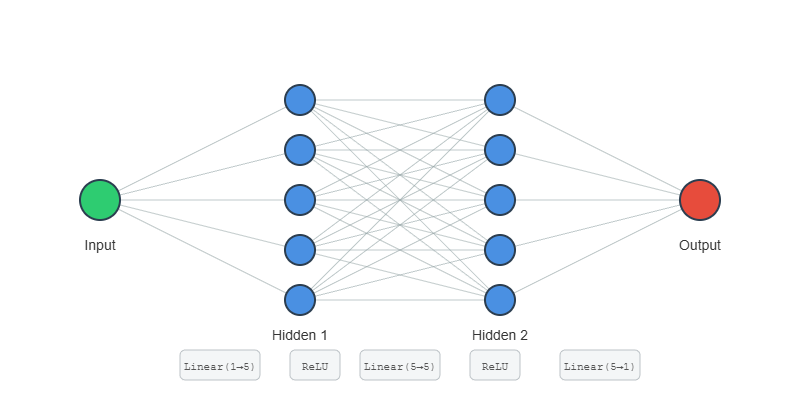

In [14]:
import torch.nn as nn

In [15]:
example_nn = nn.Sequential(
    nn.Linear(1, 5),
    nn.ReLU(),
    nn.Linear(5, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
)
print(example_nn(torch.tensor([1], dtype=torch.float32)))

tensor([0.2387], grad_fn=<ViewBackward0>)


In [16]:
example_nn

Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
for name, param in example_nn.named_parameters():
    print(f"{name}\n{param}\n\n")

0.weight
Parameter containing:
tensor([[-0.1349],
        [ 0.8999],
        [-0.8920],
        [-0.2086],
        [-0.5735]], requires_grad=True)


0.bias
Parameter containing:
tensor([-0.2110,  0.7290, -0.5448, -0.5396,  0.4961], requires_grad=True)


2.weight
Parameter containing:
tensor([[ 0.0634, -0.2347,  0.3835, -0.1536, -0.4417],
        [ 0.2289,  0.0449,  0.1223,  0.1695, -0.3605],
        [ 0.2694, -0.0090,  0.1640, -0.3987,  0.0245],
        [ 0.2358, -0.2941, -0.0896, -0.0401,  0.1375],
        [ 0.1445, -0.4032,  0.0186, -0.3162, -0.1800]], requires_grad=True)


2.bias
Parameter containing:
tensor([-6.6803e-02, -3.7168e-01,  2.1994e-01, -4.3850e-01, -4.9207e-05],
       requires_grad=True)


4.weight
Parameter containing:
tensor([[ 0.1614,  0.0286,  0.0455, -0.4369,  0.0248]], requires_grad=True)


4.bias
Parameter containing:
tensor([0.2294], requires_grad=True)




### Creating your own module

Elements like `nn.Linear` and `nn.ReLU` are inherited from `nn.Module`. It manages the parameters (weights) inserted into the modules and serves as a container for forward logic.

Thanks to this, to write your own block, you just need to inherit from `nn.Module` and write the `__init__` and `forward` methods, everything else has already been implemented for you.

`nn.Parameter` is the envelope above `torch.Tensor` that marks the tensor as a module parameter. If you assign `nn.Parameter` to the `self.something = nn.Parameter (...)` attribute, it will appear in `model.parameters ()` and be optimized by the optimizer.

`torch.nn.functional` (often imported as 'F') contains functional versions of layers and activation functions (for example, `F.relu`). Unlike modules (`nn.ReLU () `), they do not contain states and are not registered as submodules - they are useful for simple operations within forward.

In [18]:
import torch.nn.functional as F

`SkipConnection`:
$$f(x) = ReLU(Wx + b) + x$$

In [19]:
class SkipConnection(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SkipConnection, self).__init__()

        self.weight = nn.Parameter(torch.randn(hidden_size, input_size))
        self.bias = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x):
        out = F.linear(x, self.weight, self.bias)
        out = F.relu(out)
        return out + x

In [20]:
block = SkipConnection(input_size=2, hidden_size=2)

for name, param in block.named_parameters():
    print(f"{name}: {param.shape}")

input_tensor = torch.randn(4, 2)
output = block(input_tensor)

print(block)
print(f"\nOutput shape: {output.shape}")

weight: torch.Size([2, 2])
bias: torch.Size([2])
SkipConnection()

Output shape: torch.Size([4, 2])


In [21]:
example_nn_skipconn = nn.Sequential(
    nn.Linear(1, 5),
    nn.ReLU(),
    SkipConnection(input_size=5, hidden_size=5),
    nn.ReLU(),
    nn.Linear(5, 1),
)
print(example_nn_skipconn(torch.tensor([1], dtype=torch.float32)))

tensor([0.0717], grad_fn=<ViewBackward0>)


In [22]:
example_nn_skipconn

Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): ReLU()
  (2): SkipConnection()
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
)

### Modular approach

In [23]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()

        self.fc1 = nn.Linear(1, 5)
        self.fc2 = nn.Linear(5, 5)
        self.fc3 = nn.Linear(5, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x


model = SimpleNet()
input_tensor = torch.randn(10, 1)
output = model(input_tensor)

print(model)
print(f"\nOutput shape: {output.shape}")

SimpleNet(
  (fc1): Linear(in_features=1, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=5, bias=True)
  (fc3): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)

Output shape: torch.Size([10, 1])


## Fully Connected NN for classification

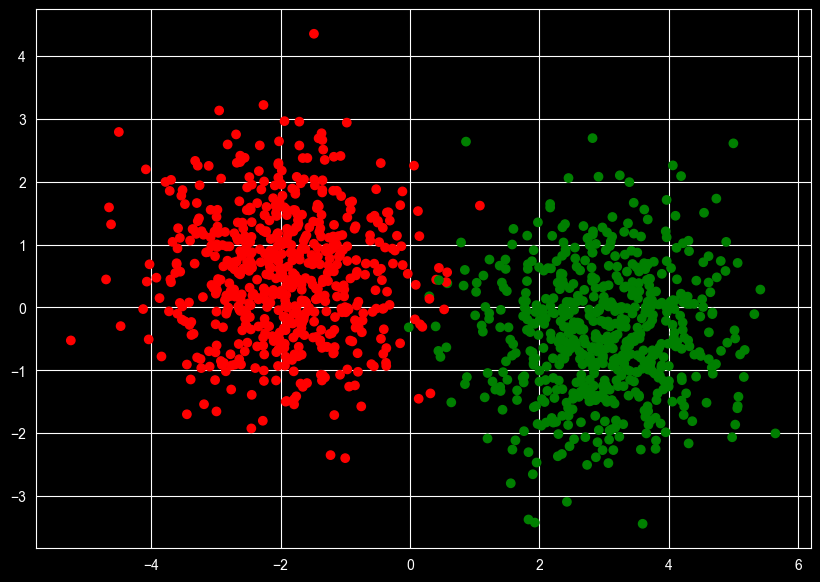

In [24]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# (-2,0.5) и (3,-0.5)
X, y = make_blobs(n_samples=1200, centers=[[-2, 0.5], [3, -0.5]], cluster_std=1, random_state=42)

colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0, 1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200)

In [26]:
X_train

array([[ 2.44814185,  2.05819929],
       [ 2.35072245, -1.72394027],
       [-1.36140754, -1.16152006],
       ...,
       [ 4.6699045 , -0.10532847],
       [-1.17059442, -1.71113531],
       [ 4.10095963,  1.45834745]], shape=(1000, 2))

In [27]:
y_train

array([1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,

In [28]:
import torch.nn as nn


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Sigmoid()

        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        """
        params:
            x (torch.Tensor):
        """

        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)
        return x

In [29]:
model = Net()

In [30]:
nn_prediction = model(torch.FloatTensor(X_test))

nn_prediction = nn_prediction.tolist()

In [31]:
nn_prediction

[[0.4287934899330139],
 [0.445636510848999],
 [0.38881227374076843],
 [0.4484648108482361],
 [0.4312019944190979],
 [0.42830079793930054],
 [0.4319830536842346],
 [0.39868831634521484],
 [0.38524195551872253],
 [0.3937591314315796],
 [0.438947856426239],
 [0.3928110897541046],
 [0.4488767981529236],
 [0.3934164345264435],
 [0.4034722149372101],
 [0.4231046438217163],
 [0.43255743384361267],
 [0.43335866928100586],
 [0.41110116243362427],
 [0.41802453994750977],
 [0.3880794644355774],
 [0.4052671194076538],
 [0.44745102524757385],
 [0.3944201171398163],
 [0.44060805439949036],
 [0.4457501769065857],
 [0.38640469312667847],
 [0.40032169222831726],
 [0.3990052342414856],
 [0.44266799092292786],
 [0.43671318888664246],
 [0.3961103558540344],
 [0.43073487281799316],
 [0.40629440546035767],
 [0.4294447898864746],
 [0.436138778924942],
 [0.39547839760780334],
 [0.4033868908882141],
 [0.44003826379776],
 [0.4244958162307739],
 [0.3998202681541443],
 [0.3984607756137848],
 [0.38675957918167114]

In [32]:
nn_prediction = np.array([int(x[0] > 0.5) for x in nn_prediction])

In [33]:
nn_prediction

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

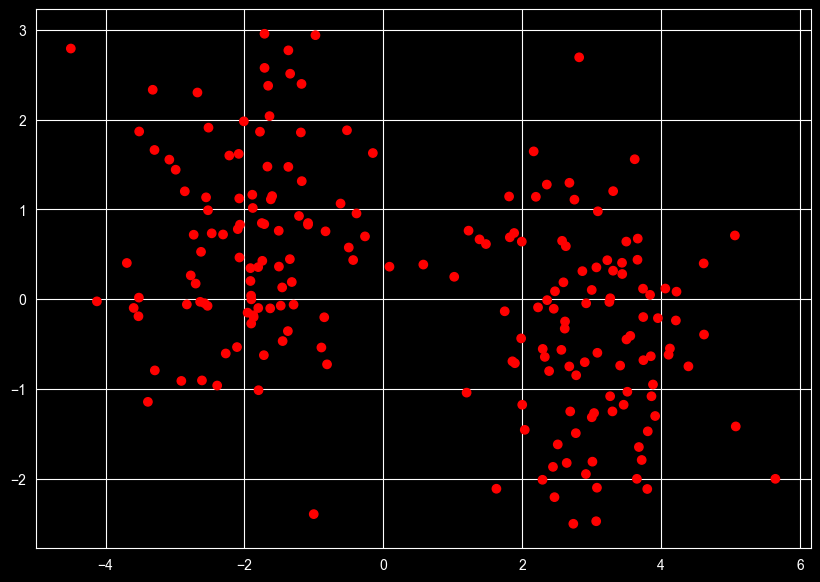

In [34]:
colors = ("red", "green")
colored_y = np.zeros(len(nn_prediction), dtype=str)

for i, cl in enumerate([0, 1]):
    colored_y[nn_prediction.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10, 7))
plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y)
plt.show()

### Training


`train()` function for training NNs.

**The following objects take part in our training:**
- NN
- loss function
- optimizer



In [35]:
import tqdm
from tqdm.auto import tqdm


def train(model, X, y, criterion, optimizer, num_epoch):
    '''
    args:
        model - model NN
        X и y - train sample
        criterion - loss function from `torch.nn`
        optimizer - optimizer from `torch.optim`
        num_epoch - number of epochs.
    '''

    for t in tqdm(range(num_epoch)):
        y_pred = model(X)

        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

    return model

/Users/user/PycharmProjects/MLC/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
model = Net()

In [37]:
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [38]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)  # size [1000] -> [1000, 1]

model = train(model, X_train, y_train, criterion, optimizer, 150)

100%|██████████| 150/150 [00:00<00:00, 7758.23it/s]


In [39]:
with torch.no_grad():
    nn_prediction = model(torch.FloatTensor(X_test))
    nn_prediction = nn_prediction.tolist()

nn_prediction = np.array([int(x[0] > 0.5) for x in nn_prediction])

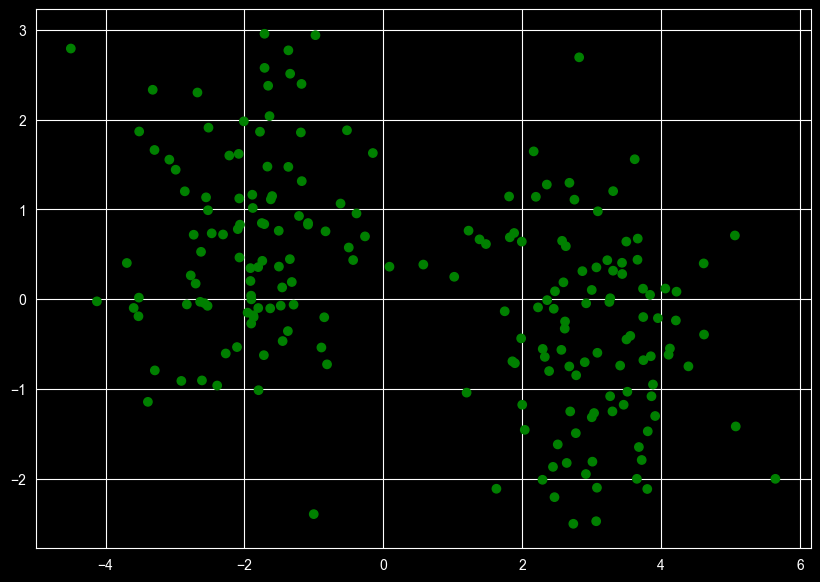

In [40]:
colors = ("red", "green")
colored_y = np.zeros(len(nn_prediction), dtype=str)

for i, cl in enumerate([0, 1]):
    colored_y[nn_prediction.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10, 7))
plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y)
plt.show()

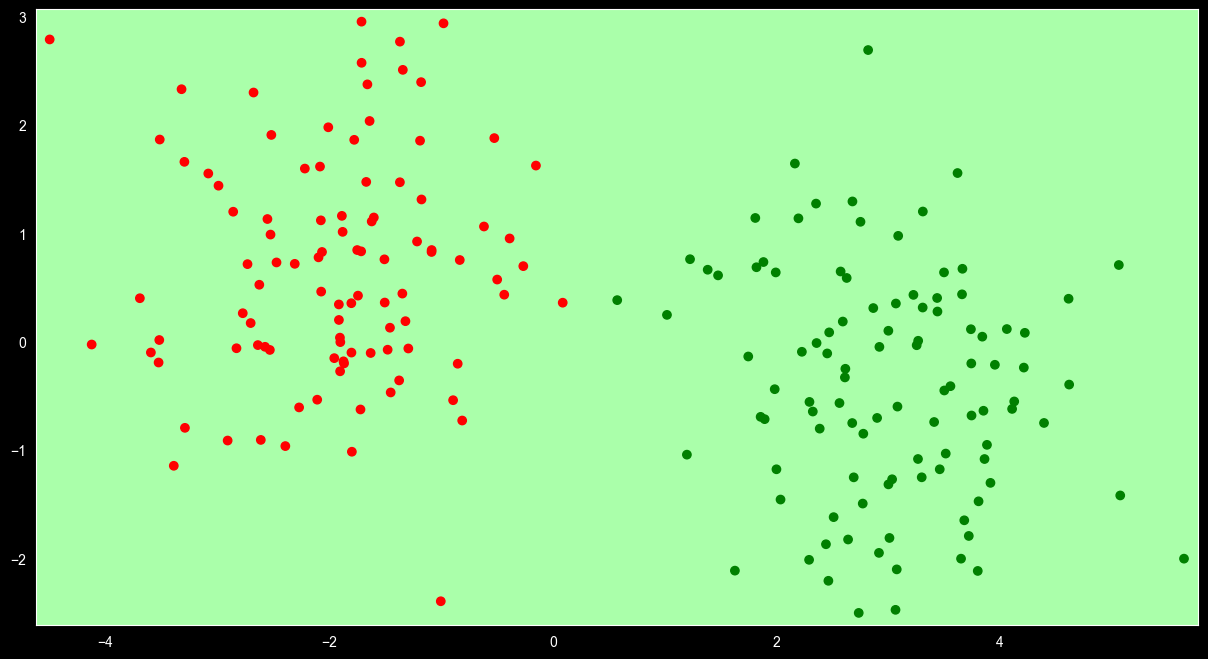

In [41]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(15, 8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X_test[:, 0]) - eps, np.max(X_test[:, 0]) + eps, 200),
                     np.linspace(np.min(X_test[:, 1]) - eps, np.max(X_test[:, 1]) + eps, 200))
Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape).detach().numpy()
Z = (Z > 0.5).astype(int)
cmap_light = ListedColormap(['#AAFFAA', '#FFAAAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

colored_y = np.zeros(y_test.size, dtype=str)
for i, cl in enumerate([0, 1]):
    colored_y[y_test.ravel() == cl] = str(colors[i])

plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y);

### Dataloader

In [42]:
train_loader = torch.utils.data.DataLoader(list(zip(X_train, y_train)), batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(list(zip(X_test, y_test)), batch_size=64, shuffle=False)

In [43]:
import tqdm
from tqdm.auto import tqdm


def train_stochastic(model, loader, criterion, optimizer, num_epoch):
    '''
    args:
        model - model NN
        X и y - train sample
        criterion - loss function from `torch.nn`
        optimizer - optimizer from `torch.optim`
        num_epoch - number of epochs.
    '''

    for t in tqdm(range(num_epoch)):
        epoch_loss = []

        for X_batch, y_batch in loader:
            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)
            epoch_loss.append(loss.item())

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print("curr_loss", np.mean(epoch_loss))

    return model

In [44]:
model = Net()
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam(NN.parameters(), lr=1e-4)

In [45]:
model = train_stochastic(model, train_loader, criterion, optimizer, 350)

 30%|██▉       | 104/350 [00:00<00:00, 516.52it/s]

curr_loss 0.7759407348930836
curr_loss 0.7756701968610287
curr_loss 0.7744513712823391
curr_loss 0.7732568792998791
curr_loss 0.7727344669401646
curr_loss 0.77164526283741
curr_loss 0.7711975835263729
curr_loss 0.7700960524380207
curr_loss 0.7688861675560474
curr_loss 0.7680244706571102
curr_loss 0.7673051543533802
curr_loss 0.7659103572368622
curr_loss 0.7654095962643623
curr_loss 0.7643172144889832
curr_loss 0.7637708745896816
curr_loss 0.7625965401530266
curr_loss 0.761731781065464
curr_loss 0.7609371691942215
curr_loss 0.7601747624576092
curr_loss 0.7590435743331909
curr_loss 0.7584389895200729
curr_loss 0.7571841515600681
curr_loss 0.75644301623106
curr_loss 0.7558387219905853
curr_loss 0.7548273913562298
curr_loss 0.7540232241153717
curr_loss 0.7528277970850468
curr_loss 0.7520794607698917
curr_loss 0.7508407682180405
curr_loss 0.7500697895884514
curr_loss 0.7495162338018417
curr_loss 0.7485862523317337
curr_loss 0.7479667030274868
curr_loss 0.7470024488866329
curr_loss 0.7461165

 62%|██████▏   | 217/350 [00:00<00:00, 546.69it/s]

curr_loss 0.6891011111438274
curr_loss 0.688454270362854
curr_loss 0.6876366622745991
curr_loss 0.6868185847997665
curr_loss 0.6860091052949429
curr_loss 0.6853219456970692
curr_loss 0.684434462338686
curr_loss 0.683700617402792
curr_loss 0.6828782893717289
curr_loss 0.6823144368827343
curr_loss 0.6815301105380058
curr_loss 0.6807352565228939
curr_loss 0.6800005286931992
curr_loss 0.6792298443615437
curr_loss 0.678505327552557
curr_loss 0.6777013838291168
curr_loss 0.6769975572824478
curr_loss 0.6761399656534195
curr_loss 0.675506517291069
curr_loss 0.6747729331254959
curr_loss 0.6741265803575516
curr_loss 0.6732677295804024
curr_loss 0.6725000031292439
curr_loss 0.6716178841888905
curr_loss 0.6710382886230946
curr_loss 0.6703371666371822
curr_loss 0.6694801859557629
curr_loss 0.6687776856124401
curr_loss 0.6681119576096535
curr_loss 0.6672854758799076
curr_loss 0.6666180901229382
curr_loss 0.6658852584660053
curr_loss 0.6651584766805172
curr_loss 0.6644549183547497
curr_loss 0.6636946

 97%|█████████▋| 338/350 [00:00<00:00, 575.01it/s]

curr_loss 0.6100795641541481
curr_loss 0.6095400080084801
curr_loss 0.6088568270206451
curr_loss 0.6080262921750546
curr_loss 0.6076665148139
curr_loss 0.607010368257761
curr_loss 0.6064539700746536
curr_loss 0.6056286171078682
curr_loss 0.6053239405155182
curr_loss 0.6044779196381569
curr_loss 0.603854525834322
curr_loss 0.6030262932181358
curr_loss 0.60256252810359
curr_loss 0.6020294390618801
curr_loss 0.6015114635229111
curr_loss 0.6008213385939598
curr_loss 0.600112859159708
curr_loss 0.5997626818716526
curr_loss 0.5988781228661537
curr_loss 0.5984137281775475
curr_loss 0.5977982133626938
curr_loss 0.5969870686531067
curr_loss 0.5963456854224205
curr_loss 0.5957377180457115
curr_loss 0.5951881669461727
curr_loss 0.5949473232030869
curr_loss 0.5941030345857143
curr_loss 0.5936107002198696
curr_loss 0.5928580164909363
curr_loss 0.5925099365413189
curr_loss 0.591610211879015
curr_loss 0.5911258235573769
curr_loss 0.5905003063380718
curr_loss 0.5899021960794926
curr_loss 0.58937307447

100%|██████████| 350/350 [00:00<00:00, 557.81it/s]

curr_loss 0.5410485938191414
curr_loss 0.5398739352822304
curr_loss 0.5395296104252338
curr_loss 0.5392665416002274
curr_loss 0.5386029034852982
curr_loss 0.5380075834691525
curr_loss 0.5375072285532951
curr_loss 0.5371705107390881
curr_loss 0.5362846031785011
curr_loss 0.536001093685627
curr_loss 0.5358105264604092
curr_loss 0.5351261384785175


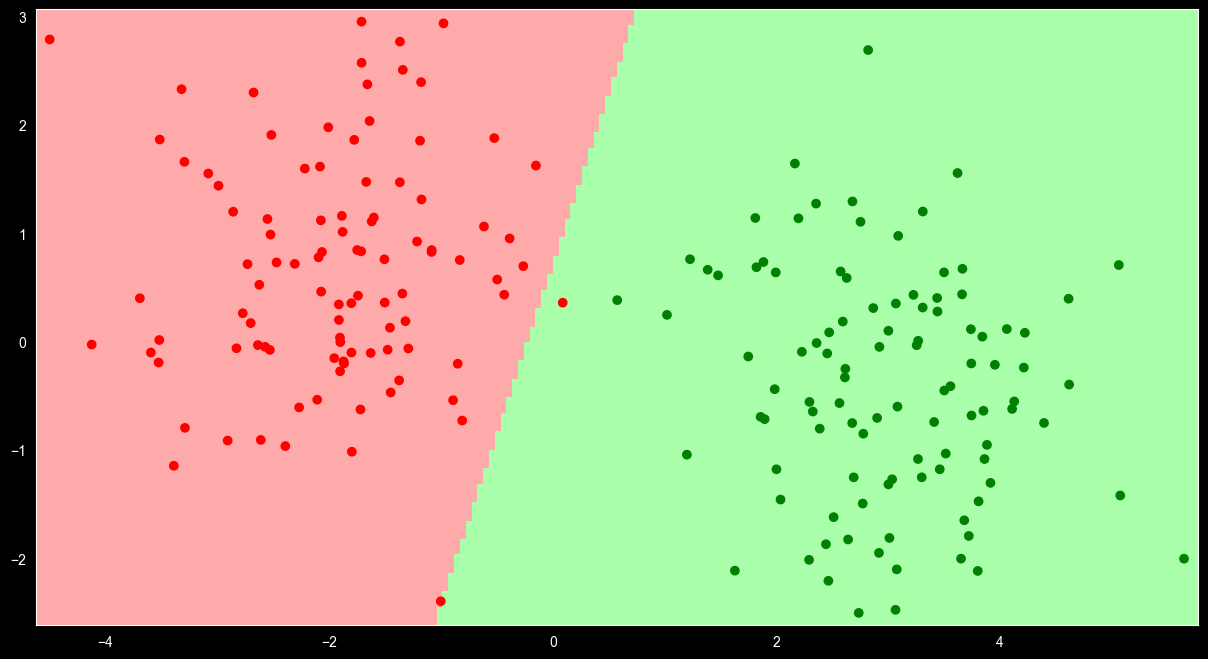

In [46]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(15, 8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X_test[:, 0]) - eps, np.max(X_test[:, 0]) + eps, 200),
                     np.linspace(np.min(X_test[:, 1]) - eps, np.max(X_test[:, 1]) + eps, 200))

Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))

Z = Z.reshape(xx.shape).detach().numpy()
Z = (Z > 0.5).astype(int)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

colored_y = np.zeros(y_test.size, dtype=str)
for i, cl in enumerate([0, 1]):
    colored_y[y_test.ravel() == cl] = str(colors[i])

plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y);

## Reference

- [Datasets & Dataloaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) (PyTorch docs)
- [Torch.autograd](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html) (PyTorch docs)